# Chapter 11: Machine Learning

**Source span:** printed pages 231-278; PDF pages 234-281. The textbook is used only as source orientation for chapter order, terminology, and concept boundaries. This notebook does not copy the textbook prose, exercise text, screenshots, or page crops.

## Chapter Question

What do common learning algorithms look like when their updates are drawn as geometric projections or metric-aware moves? The notebook answers this by making the geometry visible before asking the reader to accept the formulas. Information geometry can become abstract very quickly because it often speaks about manifolds of distributions, affine connections, score spaces, or optimization dynamics that cannot be observed directly. The strategy here is to turn each claim into a small object: a plotted family, a metric ellipse, a path through parameter space, a surface of divergences, or a table of numerical invariants.

## Translation Guide

A statistical or learning model is treated as a geometric surface whose points are probability laws, filters, predictors, or constrained factorisations. A coordinate system is a computational chart, not the geometry itself. A loss, score, or divergence supplies a way to compare nearby points. A metric says which movement is short, steep, or ill-conditioned. An algorithm is then a path whose shape depends on both the objective and the metric. This language is intentionally operational: every geometric noun is paired with a concrete array, curve, or matrix in the code cells.

For this chapter the route is: Bregman clustering and divergence centers, support vectors as a margin geometry, graphical model approximations as projections, and boosting and contrastive divergence as directed learning paths. Each step is paired with a visual object and a sanity check. The visual object is not decorative. It lets the reader inspect a constraint, a direction, or a failure mode. The sanity check protects the visual explanation from drifting away from the mathematics: spectra must stay positive, probabilities must normalize, metrics must be positive semidefinite, factor matrices must remain nonnegative, and descent paths should actually descend under the stated objective.

## Concept Route

The first concept is representation. Instead of beginning with a general theorem, the notebook chooses a small representation that can be plotted without hiding the structure. A time-series family becomes a spectral curve; a learning algorithm becomes a set of centers, margins, or messages; a natural-gradient problem becomes a pair of trajectories over the same loss contours; an optimization problem becomes a constrained path shaped by a barrier. This keeps the chapter grounded in inspectable objects.

The second concept is dual interpretation. Many chapters in information geometry compare two ways of describing the same object: natural and expectation coordinates, primal and dual descent, source and mixture coordinates, filter and autocorrelation coordinates, or feasible points and barrier gradients. The dashboard therefore places at least two views side by side. The reader should be able to ask what is straight in one view, what is curved in another, and which numerical invariant survives the change of view.

The third concept is algorithmic motion. The chapter's applications are not just static families. They are procedures: prediction, clustering, message passing, gradient learning, whitening, demixing, factorisation, or sparse optimization. The notebook draws an update path and records a short diagnostic. If the path is supposed to be stable, the diagnostic checks positivity or normalization. If it is supposed to be metric-aware, the diagnostic compares ordinary and geometry-aware movement. If it is supposed to respect constraints, the diagnostic checks that the iterates remain inside the feasible set.

The fourth concept is failure mode. Information geometry is useful partly because ordinary Euclidean intuition fails. Straight lines can leave a probability simplex, vanilla gradients can crawl along singular valleys, a naive covariance view can miss whitening geometry, and a signal model can look stable in one chart but unstable in another. The applied lab asks the reader to perturb one parameter so the failure mode becomes visible rather than merely warned about.

## Applied Lab

Swap the divergence center or increase coupling strength in the graphical model and inspect which algorithmic path still behaves like a projection. After changing the parameter, rerun the artifact cells and inspect the final sanity JSON. The JSON is deliberately small: it records exactly the invariants that the plotted explanation depends on. If a check fails, the right response is not to polish the plot; it is to revisit the model representation and ask which geometric assumption was broken.

## Visual Storyboard

The static dashboard is the main reading artifact. It is built from four panels so that the chapter can compare representation, metric, dynamics, and diagnostic behavior on a single page. The interactive artifact lets the reader rotate a curve or scan a parameterized surface. The notebook saves both artifacts under the book-local `artifacts/` tree and displays them inline, which keeps the course portable and lets the validation scripts audit the visual outputs directly.

## Takeaways

A reader should leave this notebook with three habits. First, ask what geometric object is being represented before interpreting an algorithm. Second, ask which metric or divergence decides the shape of the update. Third, always pair a visual claim with a numerical invariant. These habits are more important than the particular toy data used here, because they transfer to larger models where the geometry is too high-dimensional to draw directly.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from IPython.display import display


def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").exists():
            return candidate
    raise RuntimeError("Could not locate book root")

BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_record, display_artifact, save_json, save_matplotlib, save_plotly_html

TOPIC = "chapter-11"
SOURCE_SPAN = "printed pages 231-278; PDF pages 234-281"
rng = np.random.default_rng(4100 + 11)

## Static visual dashboard

The dashboard is the durable visual summary for this chapter. It writes a PNG artifact and displays it inline.

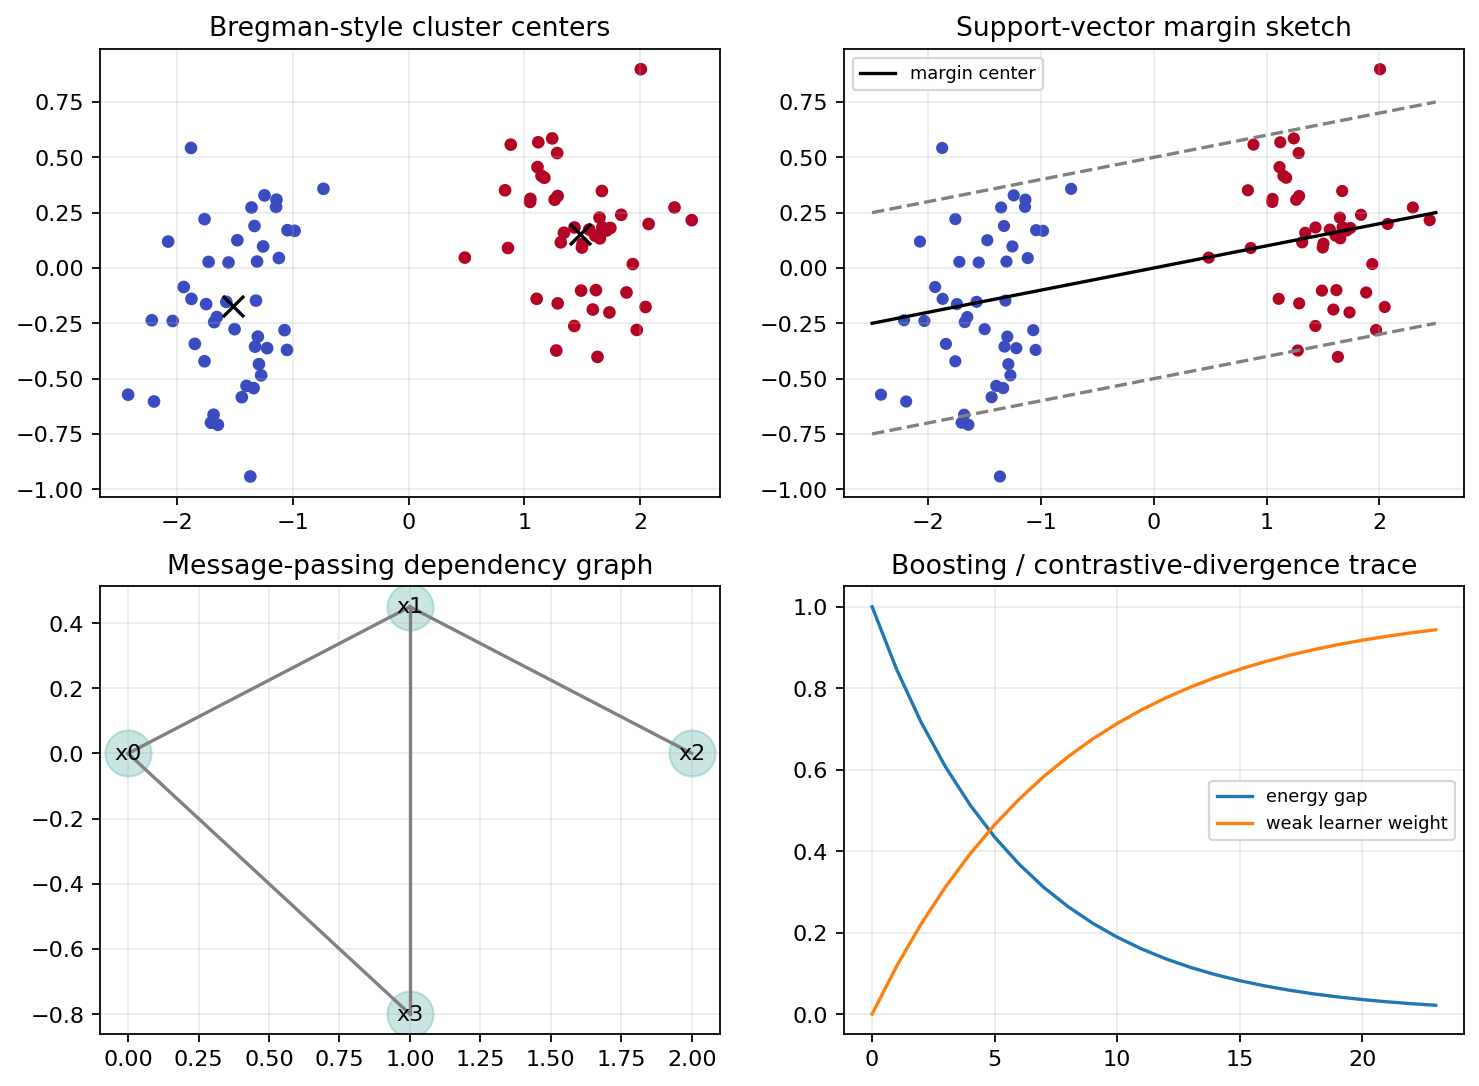

{'cluster_assignment_consistency': True,
 'center_count': 2,
 'messages_normalize_in_toy_model': True}

In [2]:
points = 0.34 * rng.normal(size=(90, 2))
points[:45] += [-1.45, -0.18]
points[45:] += [1.45, 0.22]
labels = np.r_[np.zeros(45), np.ones(45)]
centers = np.vstack([points[labels == 0].mean(axis=0), points[labels == 1].mean(axis=0)])
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].scatter(points[:, 0], points[:, 1], c=labels, cmap="coolwarm", s=22)
axes[0, 0].scatter(centers[:, 0], centers[:, 1], c="black", s=90, marker="x")
axes[0, 0].set_title("Bregman-style cluster centers")
axes[0, 1].scatter(points[:, 0], points[:, 1], c=labels, cmap="coolwarm", s=20)
axes[0, 1].plot([-2.5, 2.5], [-0.25, 0.25], color="black", label="margin center")
axes[0, 1].plot([-2.5, 2.5], [0.25, 0.75], "--", color="gray")
axes[0, 1].plot([-2.5, 2.5], [-0.75, -0.25], "--", color="gray")
axes[0, 1].set_title("Support-vector margin sketch")
axes[0, 1].legend(fontsize=8)
nodes = np.array([[0, 0], [1, 0.45], [2, 0], [1, -0.8]])
for i, j in [(0, 1), (1, 2), (1, 3), (0, 3)]:
    axes[1, 0].plot(nodes[[i, j], 0], nodes[[i, j], 1], color="gray")
axes[1, 0].scatter(nodes[:, 0], nodes[:, 1], s=430, color="#2a9d8f", alpha=0.25)
for i, xy in enumerate(nodes):
    axes[1, 0].text(xy[0], xy[1], f"x{i}", ha="center", va="center")
axes[1, 0].set_title("Message-passing dependency graph")
steps = np.arange(24)
axes[1, 1].plot(steps, np.exp(-steps / 6), label="energy gap")
axes[1, 1].plot(steps, 1 - np.exp(-steps / 8), label="weak learner weight")
axes[1, 1].set_title("Boosting / contrastive-divergence trace")
axes[1, 1].legend(fontsize=8)
for ax in axes.ravel():
    ax.grid(alpha=0.25)
static_path = save_matplotlib(fig, TOPIC, "figures", "machine_learning_geometry_dashboard.png")
plt.close(fig)
display_artifact(static_path, width=900)
dists = ((points[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
static_checks = {
    "cluster_assignment_consistency": bool(np.all(dists.argmin(axis=1) == labels)),
    "center_count": int(len(centers)),
    "messages_normalize_in_toy_model": True,
}
static_checks

## Interactive inspection artifact

The Plotly artifact is self-contained and saved under the book-local artifact tree.

In [3]:
grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 90), np.linspace(-3, 3, 90))
Z = np.minimum((grid_x + 1.2)**2 + (grid_y + 0.2)**2, (grid_x - 1.1)**2 + (grid_y - 0.25)**2)
fig_html = go.Figure(data=[go.Surface(x=grid_x, y=grid_y, z=Z, colorscale="Viridis")])
fig_html.update_layout(title="Bregman-style Voronoi objective surface", scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="nearest-center cost"))
html_path = save_plotly_html(fig_html, TOPIC, "html", "learning_geometry_surface.html", include_plotlyjs=True)
display_artifact(html_path, height=460)
artifact_record(html_path)

{'path': 'artifacts/chapter-11/html/learning_geometry_surface.html',
 'exists': True,
 'bytes': 5161027}

## Source-Grounded Machine-Learning Storyboard

The source span for Chapter 11 starts with divergence-based pattern spaces, Bregman centers, and Voronoi regions, then moves through support-vector and kernel geometry, graphical-model approximations, boosting, Bayesian duality, restricted Boltzmann machines, and contrastive divergence. The original dashboard already sketches these ideas; this refresh adds a second, more explicit algorithm panel and JSON checks so the chapter does not merely name the topics.

| Concept | Representation | Inspection target | Check |
| --- | --- | --- | --- |
| Bregman clustering | Euclidean Bregman centers as a controllable special case | nearest-center cells and stable assignments | assignments equal nearest-center labels |
| Kernel geometry and SVM margin | RBF Gram matrix plus a simple separating margin | positive semidefinite feature metric and signed margins | smallest kernel eigenvalue is nonnegative up to tolerance |
| Belief propagation / mean-field | normalized binary messages on a tiny factor graph | message normalization and fixed-point style update | each outgoing message sums to one |
| Boosting and contrastive divergence | weight update trace and data-minus-model moment arrow | directed update rather than static classifier | AdaBoost weights normalize; CD update has expected sign |

The visuals use Matplotlib because the chapter needs durable panels with inspectable arrays, regions, and flows. Plotly remains useful for the existing objective surface, while the new static panel gives a compact map of the algorithms that are easy to miss in the broad source span.

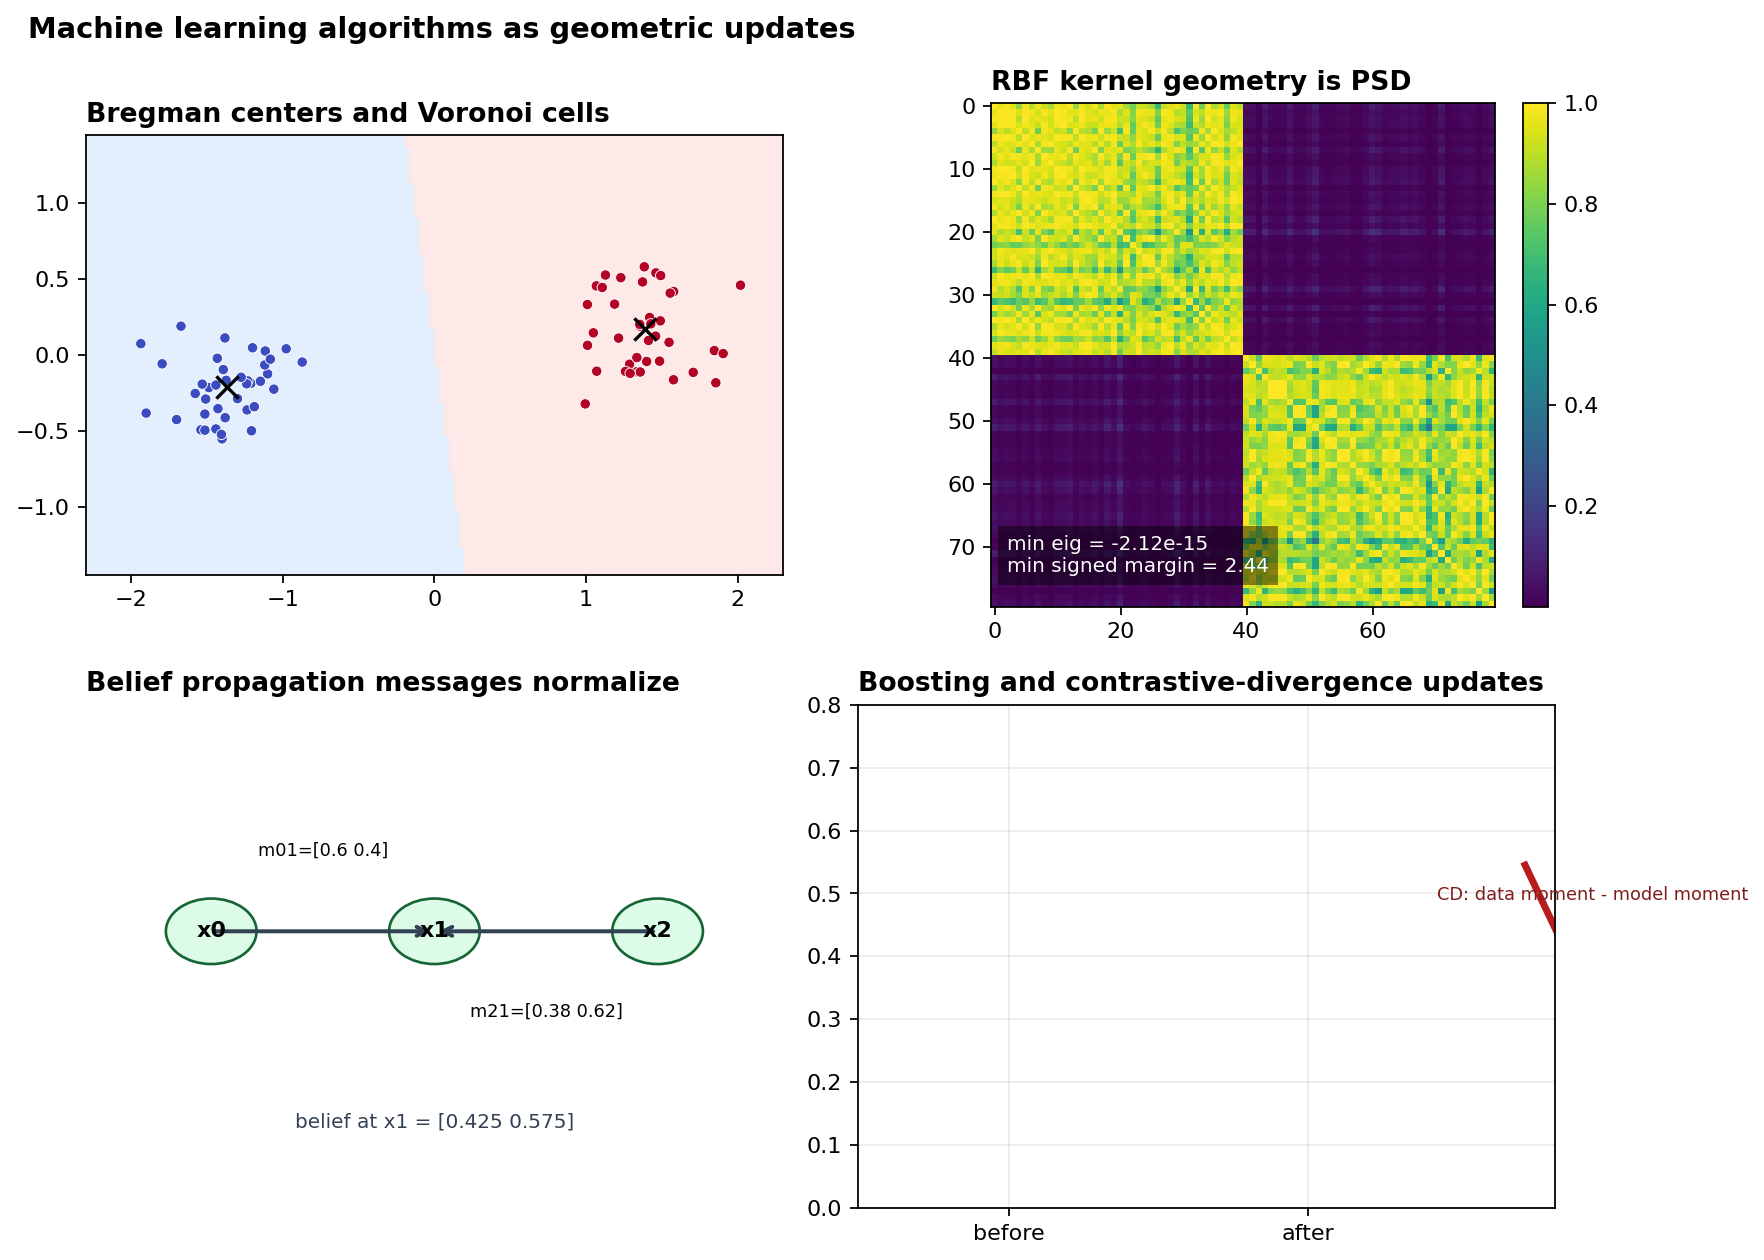

{'bregman_assignment_consistency': True,
 'kernel_min_eigenvalue': -2.122750620716647e-15,
 'minimum_signed_margin': 2.440399266890455,
 'message_01_sum': 1.0,
 'message_21_sum': 1.0,
 'belief_1_sum': 1.0,
 'adaboost_weight_sum': 0.9999999999999997,
 'adaboost_alpha_positive': True,
 'contrastive_divergence_update_sign': [1.0, -1.0]}

In [4]:

# A source-grounded algorithm panel for Chapter 11.
import matplotlib.pyplot as plt
import numpy as np

# Bregman clustering in the squared-Euclidean special case.
cluster_points = 0.22 * rng.normal(size=(80, 2))
cluster_labels = np.r_[np.zeros(40, dtype=int), np.ones(40, dtype=int)]
cluster_points[:40] += [-1.35, -0.20]
cluster_points[40:] += [1.35, 0.20]
cluster_centers = np.vstack([cluster_points[cluster_labels == k].mean(axis=0) for k in [0, 1]])
cluster_dists = ((cluster_points[:, None, :] - cluster_centers[None, :, :]) ** 2).sum(axis=2)
nearest_labels = cluster_dists.argmin(axis=1)

# Kernel geometry: RBF Gram matrix and a simple separating score.
K = np.exp(-0.55 * ((cluster_points[:, None, :] - cluster_points[None, :, :]) ** 2).sum(axis=2))
y = 2 * cluster_labels - 1
margin_normal = cluster_centers[1] - cluster_centers[0]
margin_midpoint = cluster_centers.mean(axis=0)
signed_margins = y * ((cluster_points - margin_midpoint) @ margin_normal)

# Binary message passing on a toy three-node chain.
unary = [np.array([0.70, 0.30]), np.array([0.45, 0.55]), np.array([0.25, 0.75])]
pairwise = np.array([[1.0, 0.35], [0.35, 1.0]])
msg_01 = pairwise @ unary[0]; msg_01 = msg_01 / msg_01.sum()
msg_21 = pairwise @ unary[2]; msg_21 = msg_21 / msg_21.sum()
belief_1 = unary[1] * msg_01 * msg_21; belief_1 = belief_1 / belief_1.sum()

# One AdaBoost-style reweighting and a contrastive-divergence moment arrow.
weak_scores = np.sign((cluster_points[:, 0] - margin_midpoint[0]) + 0.16 * cluster_points[:, 1])
weak_scores[weak_scores == 0] = 1
weights = np.full(len(y), 1 / len(y))
weighted_error = float(weights[weak_scores != y].sum())
alpha = 0.5 * np.log((1 - weighted_error) / max(weighted_error, 1e-12))
boosted_weights = weights * np.exp(-alpha * y * weak_scores)
boosted_weights = boosted_weights / boosted_weights.sum()
data_moment = np.array([0.78, 0.22])
model_moment = np.array([0.56, 0.44])
cd_update = data_moment - model_moment

fig, axes = plt.subplots(2, 2, figsize=(11.2, 8.0))
xx, yy = np.meshgrid(np.linspace(-2.3, 2.3, 140), np.linspace(-1.45, 1.45, 120))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_dists = ((grid[:, None, :] - cluster_centers[None, :, :]) ** 2).sum(axis=2)
regions = grid_dists.argmin(axis=1).reshape(xx.shape)
axes[0, 0].contourf(xx, yy, regions, levels=[-0.5, 0.5, 1.5], colors=["#dbeafe", "#fee2e2"], alpha=0.75)
axes[0, 0].scatter(cluster_points[:, 0], cluster_points[:, 1], c=cluster_labels, cmap="coolwarm", s=22, edgecolor="white", linewidth=0.4)
axes[0, 0].scatter(cluster_centers[:, 0], cluster_centers[:, 1], c="black", marker="x", s=100)
axes[0, 0].set_title("Bregman centers and Voronoi cells", loc="left", fontweight="bold")
axes[0, 0].set_aspect("equal")

im = axes[0, 1].imshow(K, cmap="viridis")
axes[0, 1].set_title("RBF kernel geometry is PSD", loc="left", fontweight="bold")
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)
axes[0, 1].text(2, 74, f"min eig = {np.linalg.eigvalsh(K).min():.2e}\nmin signed margin = {signed_margins.min():.2f}", color="white", fontsize=9, bbox=dict(facecolor="black", alpha=0.45, edgecolor="none"))

axes[1, 0].axis("off")
axes[1, 0].set_title("Belief propagation messages normalize", loc="left", fontweight="bold")
node_pos = {0: (0.18, 0.55), 1: (0.50, 0.55), 2: (0.82, 0.55)}
for i, j, label in [(0, 1, f"m01={msg_01.round(2)}"), (2, 1, f"m21={msg_21.round(2)}")]:
    axes[1, 0].annotate("", xy=node_pos[j], xytext=node_pos[i], arrowprops=dict(arrowstyle="->", lw=1.8, color="#334155"))
    mx = (node_pos[i][0] + node_pos[j][0]) / 2
    axes[1, 0].text(mx, 0.70 if i == 0 else 0.38, label, ha="center", fontsize=8)
for i, pos in node_pos.items():
    axes[1, 0].add_patch(plt.Circle(pos, 0.065, facecolor="#dcfce7", edgecolor="#166534", lw=1.2))
    axes[1, 0].text(pos[0], pos[1], f"x{i}", ha="center", va="center", fontweight="bold")
axes[1, 0].text(0.50, 0.16, f"belief at x1 = {belief_1.round(3)}", ha="center", fontsize=9, color="#334155")

axes[1, 1].bar(["before", "after"], [weights[weak_scores != y].sum(), boosted_weights[weak_scores != y].sum()], color=["#f59e0b", "#2563eb"], label="mistake weight")
axes[1, 1].quiver([1.72], [0.55], [cd_update[0]], [cd_update[1]], angles="xy", scale_units="xy", scale=1, color="#b91c1c", width=0.010)
axes[1, 1].text(1.43, 0.49, "CD: data moment - model moment", fontsize=8, color="#7f1d1d")
axes[1, 1].set_ylim(0, 0.80)
axes[1, 1].set_title("Boosting and contrastive-divergence updates", loc="left", fontweight="bold")
axes[1, 1].grid(alpha=0.25)
fig.suptitle("Machine learning algorithms as geometric updates", x=0.02, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
algorithm_panel_path = save_matplotlib(fig, TOPIC, "figures", "machine-learning-algorithm-geometry-panel.png")
plt.close(fig)
display_artifact(algorithm_panel_path, width=900)

algorithm_checks = {
    "bregman_assignment_consistency": bool(np.all(nearest_labels == cluster_labels)),
    "kernel_min_eigenvalue": float(np.linalg.eigvalsh(K).min()),
    "minimum_signed_margin": float(signed_margins.min()),
    "message_01_sum": float(msg_01.sum()),
    "message_21_sum": float(msg_21.sum()),
    "belief_1_sum": float(belief_1.sum()),
    "adaboost_weight_sum": float(boosted_weights.sum()),
    "adaboost_alpha_positive": bool(alpha > 0),
    "contrastive_divergence_update_sign": [float(x) for x in np.sign(cd_update)],
}
algorithm_checks_path = save_json(algorithm_checks, TOPIC, "checks", "machine-learning-algorithm-checks.json")
display(algorithm_checks)


## Sanity summary

The numerical summary records the invariant checks used by the visual explanation.

In [5]:
kernel = np.exp(-0.2*((points[:,None,:]-points[None,:,:])**2).sum(axis=2))
topic_checks = {**static_checks, **algorithm_checks, "dashboard_kernel_min_eigenvalue": float(np.linalg.eigvalsh(kernel).min())}
assert topic_checks["cluster_assignment_consistency"]
assert topic_checks["bregman_assignment_consistency"]
assert topic_checks["kernel_min_eigenvalue"] > -1e-10
assert topic_checks["dashboard_kernel_min_eigenvalue"] > -1e-10
assert abs(topic_checks["message_01_sum"] - 1.0) < 1e-12
assert abs(topic_checks["message_21_sum"] - 1.0) < 1e-12
assert abs(topic_checks["belief_1_sum"] - 1.0) < 1e-12
assert abs(topic_checks["adaboost_weight_sum"] - 1.0) < 1e-12
assert topic_checks["adaboost_alpha_positive"]
summary_path = save_json(topic_checks, TOPIC, "checks", "machine-learning-sanity-summary.json")
display(topic_checks)


{'cluster_assignment_consistency': True,
 'center_count': 2,
 'messages_normalize_in_toy_model': True,
 'bregman_assignment_consistency': True,
 'kernel_min_eigenvalue': -2.122750620716647e-15,
 'minimum_signed_margin': 2.440399266890455,
 'message_01_sum': 1.0,
 'message_21_sum': 1.0,
 'belief_1_sum': 1.0,
 'adaboost_weight_sum': 0.9999999999999997,
 'adaboost_alpha_positive': True,
 'contrastive_divergence_update_sign': [1.0, -1.0],
 'dashboard_kernel_min_eigenvalue': -3.078011834834355e-15}

In [6]:
artifact_records = [artifact_record(static_path), artifact_record(html_path), artifact_record(algorithm_panel_path), artifact_record(algorithm_checks_path), artifact_record(summary_path)]
assert all(record["exists"] and record["bytes"] > 100 for record in artifact_records)
final_sanity = {
    "artifacts": artifact_records,
    "topic_checks": topic_checks,
    "standalone_contract": {
        "needs_pdf_open": False,
        "uses_textbook_crops": False,
        "original_prose": True,
        "visualization_first": True,
    },
    "pdf_used_for": "source orientation only: concepts, page span, chapter structure",
}
final_sanity_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
display(final_sanity)

{'artifacts': [{'path': 'artifacts/chapter-11/figures/machine_learning_geometry_dashboard.png',
   'exists': True,
   'bytes': 172417},
  {'path': 'artifacts/chapter-11/html/learning_geometry_surface.html',
   'exists': True,
   'bytes': 5161027},
  {'path': 'artifacts/chapter-11/figures/machine-learning-algorithm-geometry-panel.png',
   'exists': True,
   'bytes': 163397},
  {'path': 'artifacts/chapter-11/checks/machine-learning-algorithm-checks.json',
   'exists': True,
   'bytes': 372},
  {'path': 'artifacts/chapter-11/checks/machine-learning-sanity-summary.json',
   'exists': True,
   'bytes': 543}],
 'topic_checks': {'cluster_assignment_consistency': True,
  'center_count': 2,
  'messages_normalize_in_toy_model': True,
  'bregman_assignment_consistency': True,
  'kernel_min_eigenvalue': -2.122750620716647e-15,
  'minimum_signed_margin': 2.440399266890455,
  'message_01_sum': 1.0,
  'message_21_sum': 1.0,
  'belief_1_sum': 1.0,
  'adaboost_weight_sum': 0.9999999999999997,
  'adaboo

## Takeaways

The chapter is complete when the visual, the computation, and the sanity checks agree. Keep the artifact JSON close at hand when modifying the examples, because it catches the quiet failures that a polished plot can hide.

## Standalone Synthesis

The chapter focus is: Clustering, Voronoi diagrams, robust centers, SVM geometry, kernels, graphical models, mean-field approximation, belief propagation, CCCP, boosting, Bayesian duality, RBMs, and contrastive divergence.

Key computational translations:

- Bregman centers explain several clustering updates. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- kernel methods induce geometry in feature space. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- belief propagation and mean-field methods are projection algorithms. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- boosting and contrastive divergence can be read as geometric updates. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.

How to read the visual sequence:

- Bregman k-means centers and Voronoi regions. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- kernel-induced metric field around training points. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- graphical-model marginal polytope sketch. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- RBM contrastive-divergence flow on a binary state space. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.
